# 0. Libraries

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from feature_engine.imputation import MeanMedianImputer
from feature_engine.selection import DropConstantFeatures, SmartCorrelatedSelection, DropDuplicateFeatures
from feature_engine.outliers import Winsorizer
from feature_engine.transformation import YeoJohnsonTransformer
from sklearn.preprocessing import StandardScaler
import os

import warnings
warnings.filterwarnings('ignore')

# Suppress TensorFlow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 1. Reading Clean Dataset:

In [31]:
merged_df = pd.read_csv('./3-DNN_Baseline/V2-merged_df_noOutliers.csv')
merged_df.head(2)

,cid,Smiles,Standard Value,pIC50 Value,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,...,3d-P2s,3d-E1s,3d-E2s,3d-E3s,3d-Ts,3d-As,3d-Vs,3d-Ks,3d-Ds,QT-pIC50 Value
0,23647975,COc1cc(cc(Cc2cnc(N)nc2N)c1OC)C#CCCCC(O)=O,34.0,7.468521,1,-0.9874,0.974959,55.7857,55.717446,12,...,0.270792,0.568703,0.404621,0.409698,22.863896,123.556813,272.29810,0.506905,1.383022,0.624900
1,5578,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,2722.0,5.565112,0,-1.1990,1.437601,34.9926,43.448274,12,...,0.223644,0.526743,0.420964,0.415681,15.650156,58.403017,129.62338,0.521793,1.363389,-0.538272


# 2a. Reading Ligand descriptors file: 2D and FP Only

In [32]:
merged_df.shape

(873, 2761)

In [33]:
# Dropping all columns with the prefix 'PubchemFP'
merged_df = merged_df.loc[:, ~merged_df.columns.str.startswith('3d-')]

# Display the new shape of df_lig:
print(merged_df.shape)

(873, 2330)


# 3. Features

## 3.1. Splitting Data

In [34]:
# Reset Indexes:
merged_df = merged_df.reset_index(drop=True)

In [35]:
# FOR MODEL

X = merged_df.drop(columns = ['Standard Value','pIC50 Value','Smiles','QT-pIC50 Value','cid'])
y = merged_df['pIC50 Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state = 42)

## 3.2. Missing Data Imputation

In [36]:
# Initialize the imputer with median imputation method
imputer = MeanMedianImputer(imputation_method='median')

# Fit the imputer to the training data
imputer.fit(X_train)

# Transform the training data
X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)


## 3.3. Removing Constants and Dublicated

In [37]:
%%time

# Drop constant
drop_const = DropConstantFeatures(tol=0.999)

drop_const.fit(X_train)
X_train = drop_const.transform(X_train)
X_test = drop_const.transform(X_test)

print(X_train.shape)

# Drop duplicates
drop_dup = DropDuplicateFeatures()

drop_dup.fit(X_train)
X_train = drop_dup.transform(X_train)
X_test = drop_dup.transform(X_test)

print(X_train.shape)

(742, 1690)
(742, 1427)
CPU times: user 727 ms, sys: 12.2 ms, total: 739 ms
Wall time: 742 ms


## 3.4. Outliers

In [38]:
%time

# Initialize Winsorizer transformer
winsorizer = Winsorizer(capping_method='gaussian', tail='both')

# Fit and transform on training data
winsorizer.fit(X_train)

X_train = winsorizer.transform(X_train)
X_test = winsorizer.transform(X_test)

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 8.34 µs


## 3.5. YeoJohnsonTransformer:

In [39]:
%time

from feature_engine.transformation import YeoJohnsonTransformer

yeo_trans = YeoJohnsonTransformer()
yeo_trans.fit(X_train)

X_train = yeo_trans.transform(X_train)
X_test = yeo_trans.transform(X_test)

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 8.58 µs


## 3.6. Scaling:

In [40]:
%time

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Instantiate the StandardScaler
scaler = StandardScaler()

# Fit and transform on the training data
scaler.fit(X_train)

# Scale the training data
X_train_eda = scaler.transform(X_train)
X_test_eda = scaler.transform(X_test)

# Convert the numpy arrays back to DataFrames and assign column names
X_train = pd.DataFrame(X_train_eda, columns=X_train.columns)
X_test = pd.DataFrame(X_test_eda, columns=X_test.columns)

CPU times: user 0 ns, sys: 6 µs, total: 6 µs
Wall time: 15.5 µs


## 3.7. Multiple ANN Model (Average of 5 runs)

In [41]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize variables to store results
y_preds = []
maes = []
r2_scores = []

# Run the model 5 times
for i in range(5):
    print(f"Running model {i + 1}")
    # Define the neural network model
    model_1 = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(16, activation='relu'),
        BatchNormalization(),
        Dense(1, activation='linear')
    ])

    # Compile the model
    optimizer = Adam(learning_rate=0.0007)
    model_1.compile(
        optimizer=optimizer,
        loss='mean_squared_error',
        metrics=['mae']
    )

    # Apply learning rate reduction on plateau
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=20, min_lr=0.000001)

    # Define the EarlyStopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True
    )

    # Train the model
    history_improved = model_1.fit(
        X_train,
        y_train,
        batch_size=32,
        epochs=200,  # Reduced to 10 epochs for quicker testing
        validation_data=(X_test, y_test),
        shuffle=True,
        verbose=0,
        callbacks=[reduce_lr, early_stopping]
    )

    # Predict on the test set
    y_pred = model_1.predict(X_test)
    y_preds.append(y_pred.flatten())

    # Calculate MAE and R^2
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Append MAE and R^2 to lists
    maes.append(mae)
    r2_scores.append(r2)

    # Delete the model to free up memory before the next iteration
    del model_1

# Convert y_preds list to a DataFrame
y_preds_df = pd.DataFrame(y_preds).T
y_preds_df.columns = [f'y_pred_run_{i+1}' for i in range(5)]
y_preds_df.index = y_test.index  # Use the same index as y_test

# Calculate the average y_pred across all runs
y_preds_df['average_y_pred'] = y_preds_df.mean(axis=1)

# Add y_test to the DataFrame
y_preds_df['y_test'] = y_test

# Calculate MAE and R^2 for the average predictions
average_mae = mean_absolute_error(y_test, y_preds_df['average_y_pred'])
average_r2 = r2_score(y_test, y_preds_df['average_y_pred'])

# Create a summary DataFrame
summary_df = pd.DataFrame({
    'Run': [f'Run {i+1}' for i in range(5)] + ['Average'],
    'R2': r2_scores + [average_r2],
    'MAE': maes + [average_mae]
})

Running model 1
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Running model 2
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Running model 3
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Running model 4
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Running model 5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [42]:
y_preds_df.head(10)

,y_pred_run_1,y_pred_run_2,y_pred_run_3,y_pred_run_4,y_pred_run_5,average_y_pred,y_test
795,7.838820,7.721936,7.551853,7.944912,7.437052,7.698915,7.886057
319,5.330712,5.461563,5.298988,4.995077,5.286096,5.274487,5.769551
382,7.480074,7.209823,7.559738,7.148133,7.301731,7.339900,7.244125
737,5.654628,5.617939,5.561243,5.562329,5.209064,5.521041,5.387216
422,6.422741,6.503764,6.232037,6.395277,6.611565,6.433076,6.008774
327,5.960204,5.960826,6.174911,6.385067,6.466824,6.189567,6.853872
804,6.923310,7.068254,7.291543,7.128766,7.732928,7.228961,7.000000
136,8.089792,7.872782,8.234277,8.343882,7.940978,8.096342,8.698970
670,4.557523,4.766030,4.760529,4.563537,4.849462,4.699416,4.812479
777,4.445237,4.467396,4.573514,4.317849,4.402678,4.441335,4.158641


In [43]:
summary_df

,Run,R2,MAE
0,Run 1,0.747224,0.473118
1,Run 2,0.744052,0.469496
2,Run 3,0.740235,0.467512
3,Run 4,0.749842,0.473450
4,Run 5,0.731575,0.461937
5,Average,0.757740,0.452320


## 3.8. Saveing Output:

In [44]:
y_preds_df['Relative_Error_%'] = (y_preds_df['average_y_pred'] - y_preds_df['y_test'])/y_preds_df['y_test'] * 100
y_preds_df.head()

,y_pred_run_1,y_pred_run_2,y_pred_run_3,y_pred_run_4,y_pred_run_5,average_y_pred,y_test,Relative_Error_%
795,7.838820,7.721936,7.551853,7.944912,7.437052,7.698915,7.886057,-2.373076
319,5.330712,5.461563,5.298988,4.995077,5.286096,5.274487,5.769551,-8.580626
382,7.480074,7.209823,7.559738,7.148133,7.301731,7.339900,7.244125,1.322104
737,5.654628,5.617939,5.561243,5.562329,5.209064,5.521041,5.387216,2.484117
422,6.422741,6.503764,6.232037,6.395277,6.611565,6.433076,6.008774,7.061382


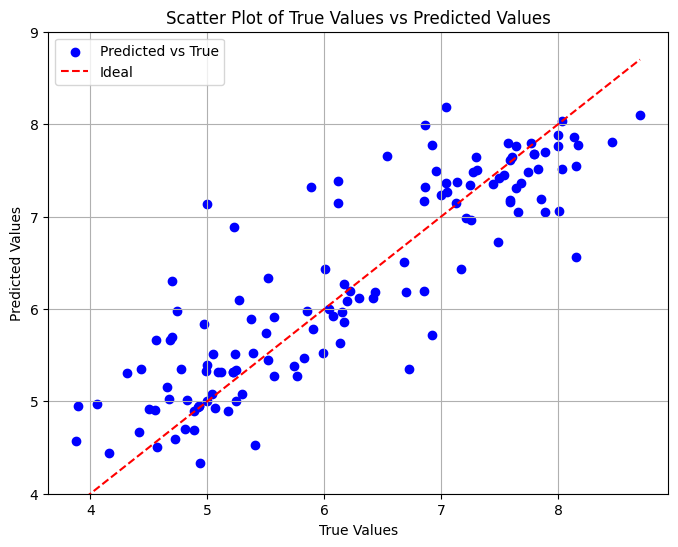

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Creating the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_preds_df['y_test'], y_preds_df['average_y_pred'], color='blue', label='Predicted vs True')

# Adding the red line representing the ideal case (y = x)
min_val = min(y_preds_df['y_test'].min(), y_preds_df['average_y_pred'].min())
max_val = max(y_preds_df['y_test'].max(), y_preds_df['average_y_pred'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal')

# Limiting the y-axis to the range [4, 9]
plt.ylim(4, 9)

# Adding title, labels, grid, and legend
plt.title('Scatter Plot of True Values vs Predicted Values')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.legend()
plt.show()


In [46]:
# Save the updated DataFrame to a CSV file
y_preds_df.to_csv('output_model_2d_fp_all_avrg.csv', index=False)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

log_target_test = y_preds_df['Relative_Error_%']

plt.figure(figsize=(4, 6))

# Create the box plot with adjusted box width and frame thickness
box = plt.boxplot([log_target_test], 
                  vert=True, patch_artist=True, widths=0.6,  # Increase the box width
                  boxprops=dict(facecolor='none', color='darkblue', linewidth=1),  # Thinner box frame
                  medianprops=dict(color='darkblue', linewidth=1.5), 
                  whiskerprops=dict(color='darkblue', linewidth=1.5),
                  capprops=dict(color='darkblue', linewidth=1.5), 
                  flierprops=dict(marker='o', color='red', alpha=0.5))

# Change the color of the box
colors = ['#a6d854']
for box_patch, color in zip(box['boxes'], colors):
    box_patch.set(facecolor=color, alpha=0.6)

# Add grid lines
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add a title and labels with custom font sizes
plt.title('Box Plot of Relative Error (%)', fontsize=20, weight='bold')
plt.ylabel('Relative Error (%)', fontsize=18, weight='bold')
plt.xticks([1], ['Target (pIC50)'], fontsize=18, weight='bold')

# Adding median value as text, positioned above the box plot
median = box['medians'][0].get_ydata()[0]
plt.text(1, median + 2, f'{median:.2f}', horizontalalignment='center', color='darkblue', weight='semibold', va='center', fontsize=16)

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=14)
plt.ylim(-60, 60)  # Set y-axis limit
plt.tight_layout()

# Display the plot
plt.show()


KeyboardInterrupt: 